<a href="https://colab.research.google.com/github/Jeffquintao/MVP-Qualidade-de-Software-Seguran-a-e-Sistemas-Inteligentes/blob/main/obesity_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Classificação de Níveis de Obesidade
## Dataset: Estimation of Obesity Levels Based on Eating Habits and Physical Condition
**Fonte:** UCI Machine Learning Repository (ID: 544)

Link do dataset: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

Este notebook classifica o nível de obesidade de indivíduos com base em hábitos alimentares e condição física, utilizando os algoritmos:
- **KNN** (K-Nearest Neighbors)
- **Árvore de Classificação** (Decision Tree)
- **Naive Bayes**
- **SVM** (Support Vector Machine)

**Classes alvo:**
- Insufficient_Weight
- Normal_Weight
- Overweight_Level_I
- Overweight_Level_II
- Obesity_Type_I
- Obesity_Type_II
- Obesity_Type_III

---
## 📦 1. Instalação e Importação de Dependências

In [40]:
# Instalar biblioteca UCI
!pip install ucimlrepo -q
!pip install scikit-learn==1.8.0 -q

In [41]:
# ── Bibliotecas gerais ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dataset ─────────────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

# ── Pré-processamento ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# ── Algoritmos ───────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# ── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

# ── Exportação ────────────────────────────────────────────────────────────────
import joblib

# Seed global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


---
## 📂 2. Carga dos Dados

In [42]:
# Carrega o dataset diretamente do UCI ML Repository (ID=544)
dataset = fetch_ucirepo(id=544)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

print("📊 Metadados do Dataset")
print(f"  Nome    : {dataset.metadata['name']}")
print(f"  Registros: {X_raw.shape[0]}")
print(f"  Features : {X_raw.shape[1]}")
print(f"  Classes  : {y_raw.iloc[:, 0].nunique()}")

📊 Metadados do Dataset
  Nome    : Estimation of Obesity Levels Based On Eating Habits and Physical Condition 
  Registros: 2111
  Features : 16
  Classes  : 7


In [43]:
# Consolidar em um único DataFrame para exploração
df = X_raw.copy()
df['NObeyesdad'] = y_raw.values.ravel()

# Dados disponíveis no dataset

# Gender = Gênero: Masculino (Male) ou Feminino (Female)
# Age = Idade (faixa entre 14 e 61 anos)
# Height = Altura (faixa entre 1,45 e 1,98m)
# Weight = Peso (faixa entre 39 e 173kg)
# family_history_with_overweight = Histórico familiar de sobrepeso: valores sim ou não.
# FAVC = Consumo frequente de alimentos calóricos: valores sim ou não.
# FCVC = frequência de consumo de vegetais por refeição: escala de 1(nunca) a 3(sempre).
# NCP = número de refeições por dia: escala de 1 a 4 refeições.
# CAEC = hábito de comer entre as refeições(beliscar): valores - não, as vezes, frequentemente e sempre.
# Smoke = Se o indivíduo é fumante: valores sim ou não.
# CH20 = Consumo de água por dia em litros: escala de 1 a 3(pouco, moderado e muito).
# SCC = Se o indivíduo monitora o consumo de calorias: valores sim ou não.
# FAF = frequência de atividades físicas: escala de 0 (nunca) e 3 (intensa).
# TUE = Horas por dia em dispositivos móveis(sedentarismo): escala de 0 a 2 horas.
# CALC = consumo de álcool: valores - não, as vezes, frequentemente e sempre.
# MTRANS = meio de transporte que habitualmente utiliza: valores - automóvel, moto, bicicleta, transporte público e caminha.
# NObeyesdad = Nível de obesidade: valores - abaixo do peso, peso normal, acima de peso 1, acima do peso 2, obesidade 1, obesidade 2 e obesidade 3.

print("Primeiras linhas:")
df.head()

Primeiras linhas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [44]:
print("\n📋 Informações gerais:")
df.info()


📋 Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF        

---
## 🔧 3. Transformação dos Dados

### 3.1 Encoding de Variáveis Categóricas

In [45]:
# Identifica colunas categóricas (exceto o alvo)
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas categóricas: {cat_cols}")

# Aplica Label Encoding nas features categóricas
X = X_raw.copy()
le_features = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_features[col] = le

# Codifica a variável alvo
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw.values.ravel())

print("\n✅ Encoding concluído.")
print(f"Classes codificadas: {list(le_target.classes_)}")

Colunas categóricas: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

✅ Encoding concluído.
Classes codificadas: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


### 3.2 Separação Treino / Teste (Holdout 80/20)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          # mantém proporção das classes
    random_state=SEED
)

print(f"📊 Tamanho do conjunto de treino : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Tamanho do conjunto de teste  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nNúmero de features: {X_train.shape[1]}")

📊 Tamanho do conjunto de treino : 1688 amostras (80.0%)
📊 Tamanho do conjunto de teste  : 423 amostras (20.0%)

Número de features: 16


---
## 🤖 4. Modelagem com Pipelines

> Cada pipeline encapsula **pré-processamento (StandardScaler)** + **classificador**, garantindo que a normalização seja ajustada **apenas** nos dados de treino (sem data leakage).

### 4.1 Definição dos Pipelines Base

In [47]:
# Estratégia de Cross-Validation: Stratified K-Fold com 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# ── Pipelines com StandardScaler ────────────────────────────────────────────
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),   # scaler incluído por consistência
        ('clf', DecisionTreeClassifier(random_state=SEED))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', MinMaxScaler()),     # MinMaxScaler para NB (valores ≥ 0)
        ('clf', GaussianNB())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=SEED, probability=True))
    ]),
}

print("✅ Pipelines criados:")
for name in pipelines:
    print(f"   • {name}")

✅ Pipelines criados:
   • KNN
   • Decision Tree
   • Naive Bayes
   • SVM


### 4.2 Cross-Validation com Hiperparâmetros Padrão

In [48]:
print("🔄 Avaliação inicial com cross-validation (10-fold)...\n")

cv_results_base = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results_base[name] = scores
    print(f"  {name:20s} → Acurácia: {scores.mean():.4f} ± {scores.std():.4f}")

🔄 Avaliação inicial com cross-validation (10-fold)...

  KNN                  → Acurácia: 0.8039 ± 0.0247
  Decision Tree        → Acurácia: 0.9319 ± 0.0261
  Naive Bayes          → Acurácia: 0.5741 ± 0.0295
  SVM                  → Acurácia: 0.8768 ± 0.0259


---
## ⚙️ 5. Otimização de Hiperparâmetros (GridSearchCV)

In [49]:
# Grids de hiperparâmetros para cada algoritmo
param_grids = {
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 11, 15],
        'clf__weights'    : ['uniform', 'distance'],
        'clf__metric'     : ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'clf__max_depth'       : [None, 5, 10, 15, 20],
        'clf__criterion'       : ['gini', 'entropy'],
        'clf__min_samples_split': [2, 5, 10]
    },
    'Naive Bayes': {
        'clf__var_smoothing': np.logspace(-12, -6, 7)
    },
    'SVM': {
        'clf__C'     : [0.1, 1, 10, 100],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma' : ['scale', 'auto']
    },
}

best_models = {}
grid_results = {}

print("🔍 Iniciando GridSearchCV (pode demorar alguns minutos)...\n")

for name, pipe in pipelines.items():
    print(f"  Otimizando {name}...", end=' ', flush=True)
    gs = GridSearchCV(
        estimator  = pipe,
        param_grid = param_grids[name],
        cv         = cv,
        scoring    = 'accuracy',
        n_jobs     = -1,
        refit      = True
    )
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    grid_results[name] = gs
    print(f"✅  Best CV Acc: {gs.best_score_:.4f} | Params: {gs.best_params_}")

🔍 Iniciando GridSearchCV (pode demorar alguns minutos)...

  Otimizando KNN... ✅  Best CV Acc: 0.8750 | Params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
  Otimizando Decision Tree... ✅  Best CV Acc: 0.9402 | Params: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 10}
  Otimizando Naive Bayes... ✅  Best CV Acc: 0.5770 | Params: {'clf__var_smoothing': np.float64(1e-06)}
  Otimizando SVM... ✅  Best CV Acc: 0.9656 | Params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


---
## 📊 6. Avaliação e Comparação dos Modelos

### 6.1 Resultados no Conjunto de Teste

In [50]:
class_names = le_target.classes_

results_summary = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt  = f1_score(y_test, y_pred, average='weighted')
    cv_acc = grid_results[name].best_score_

    results_summary.append({
        'Modelo'         : name,
        'CV Acc (treino)': cv_acc,
        'Acc (teste)'    : acc,
        'F1 Macro'       : f1_mac,
        'F1 Weighted'    : f1_wt,
    })

    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f" CV Accuracy (treino) : {cv_acc:.4f}")
    print(f" Accuracy    (teste)  : {acc:.4f}")
    print(f" F1 Macro             : {f1_mac:.4f}")
    print(f" F1 Weighted          : {f1_wt:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

results_df = pd.DataFrame(results_summary).set_index('Modelo')
print("\n📋 Tabela Resumo:")
results_df.style.highlight_max(color='lightgreen').format("{:.4f}")


 KNN
 CV Accuracy (treino) : 0.8750
 Accuracy    (teste)  : 0.8723
 F1 Macro             : 0.8670
 F1 Weighted          : 0.8692

                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.94      0.91        54
      Normal_Weight       0.76      0.64      0.69        58
     Obesity_Type_I       0.82      0.93      0.87        70
    Obesity_Type_II       0.94      0.98      0.96        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.83      0.76      0.79        58
Overweight_Level_II       0.87      0.83      0.85        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423


 Decision Tree
 CV Accuracy (treino) : 0.9402
 Accuracy    (teste)  : 0.9362
 F1 Macro             : 0.9357
 F1 Weighted          : 0.9362

                     precision    recall  f1-score   s

,CV Acc (treino),Acc (teste),F1 Macro,F1 Weighted
Modelo,,,,
KNN,0.8750,0.8723,0.8670,0.8692
Decision Tree,0.9402,0.9362,0.9357,0.9362
Naive Bayes,0.5770,0.6052,0.5792,0.5807
SVM,0.9656,0.9716,0.9707,0.9716


### 6.2 Gráfico Comparativo

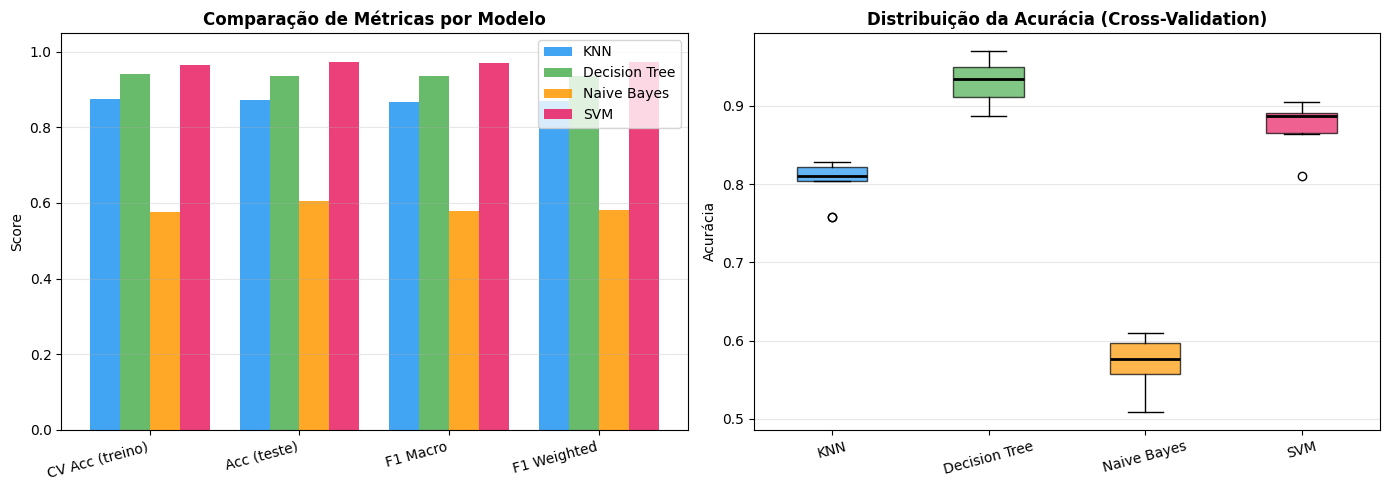

📁 Gráfico salvo: comparacao_modelos.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['CV Acc (treino)', 'Acc (teste)', 'F1 Macro', 'F1 Weighted']
x = np.arange(len(metrics))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
width = 0.20

# ── Gráfico de barras agrupadas ──────────────────────────────────────────────
ax = axes[0]
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Comparação de Métricas por Modelo', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Cross-validation boxplot ─────────────────────────────────────────────────
ax2 = axes[1]
cv_data = [cv_results_base[name] for name in cv_results_base]
bp = ax2.boxplot(cv_data, labels=list(cv_results_base.keys()), patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('Distribuição da Acurácia (Cross-Validation)', fontweight='bold')
ax2.set_ylabel('Acurácia')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Gráfico salvo: comparacao_modelos.png")

### 6.3 Matrizes de Confusão

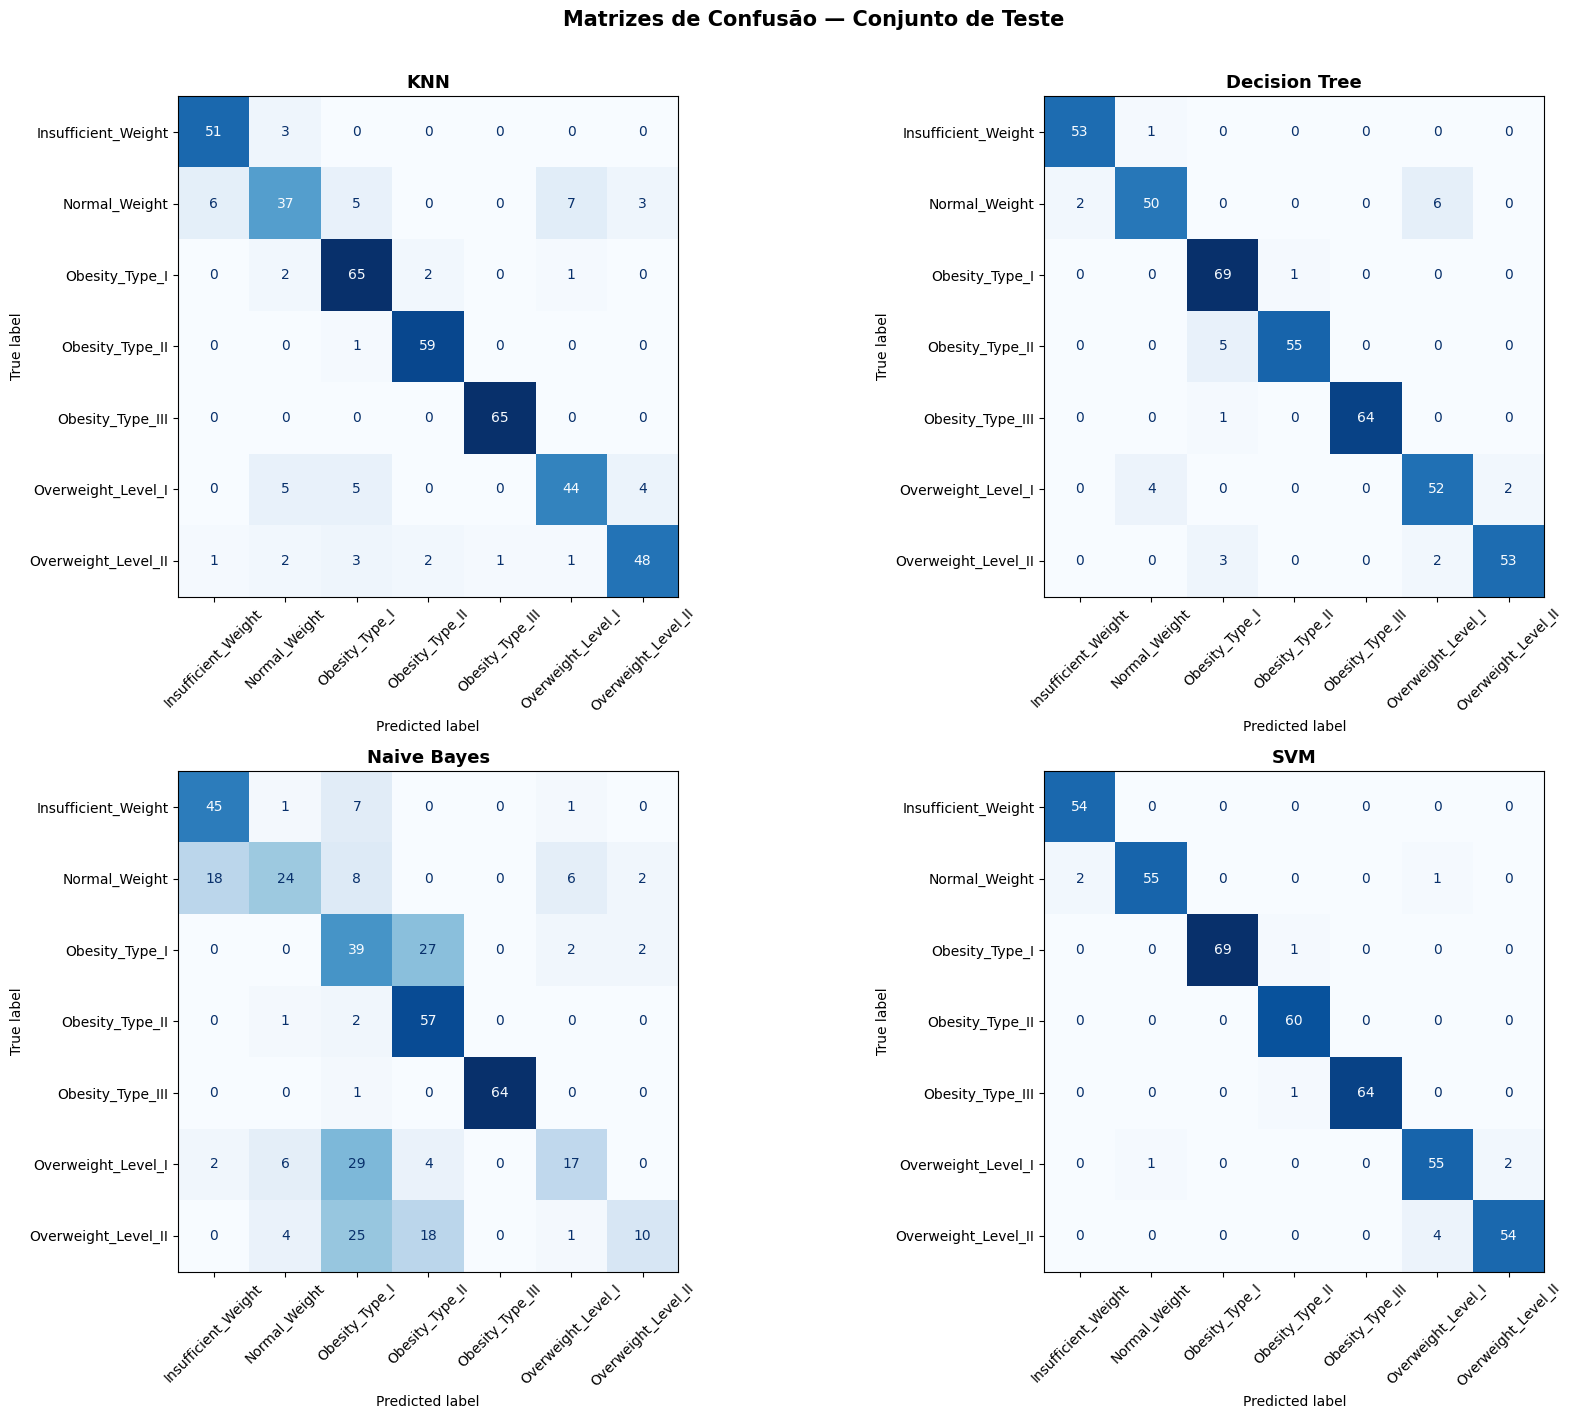

📁 Gráfico salvo: matrizes_confusao.png


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Gráfico salvo: matrizes_confusao.png")

### 6.4 Identificação do Melhor Modelo

In [53]:
best_model_name = results_df['Acc (teste)'].idxmax()
best_model_acc  = results_df['Acc (teste)'].max()
best_pipeline   = best_models[best_model_name]

print(f"🏆 Melhor modelo: {best_model_name}")
print(f"   Acurácia no teste  : {best_model_acc:.4f} ({best_model_acc*100:.2f}%)")
print(f"   F1 Weighted        : {results_df.loc[best_model_name, 'F1 Weighted']:.4f}")
print(f"   CV Acc (treino)    : {results_df.loc[best_model_name, 'CV Acc (treino)']:.4f}")
print(f"\n   Melhores hiperparâmetros: {grid_results[best_model_name].best_params_}")

🏆 Melhor modelo: SVM
   Acurácia no teste  : 0.9716 (97.16%)
   F1 Weighted        : 0.9716
   CV Acc (treino)    : 0.9656

   Melhores hiperparâmetros: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


---
## 💾 7. Exportação do Modelo

In [54]:
# Salva o melhor pipeline (inclui o pré-processador + classificador)
model_filename = f'best_model_{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_pipeline, model_filename)
print(f"✅ Modelo exportado: {model_filename}")

# Salva também os encoders e metadata
metadata = {
    'best_model_name'  : best_model_name,
    'le_target'        : le_target,
    'le_features'      : le_features,
    'feature_names'    : list(X.columns),
    'class_names'      : list(class_names),
    'test_accuracy'    : best_model_acc,
    'best_params'      : grid_results[best_model_name].best_params_,
}
joblib.dump(metadata, 'model_metadata.pkl')
print("✅ Metadata exportada: model_metadata.pkl")

✅ Modelo exportado: best_model_svm.pkl
✅ Metadata exportada: model_metadata.pkl


---
## 🔮 8. Demonstração de Predição com o Modelo Exportado

In [55]:
# Carrega o modelo salvo
loaded_model    = joblib.load(model_filename)
loaded_metadata = joblib.load('model_metadata.pkl')

print("✅ Modelo carregado com sucesso!")
print(f"   Modelo: {loaded_metadata['best_model_name']}")
print(f"   Acurácia (teste): {loaded_metadata['test_accuracy']:.4f}")

# Exemplo de predição em novos dados (usando uma amostra do conjunto de teste)
sample = X_test.iloc[:5].copy()
predictions = loaded_model.predict(sample)
pred_labels = loaded_metadata['le_target'].inverse_transform(predictions)
true_labels = loaded_metadata['le_target'].inverse_transform(y_test[:5])

print("\n🎯 Predições de exemplo:")
for i, (pred, true) in enumerate(zip(pred_labels, true_labels)):
    status = '✅' if pred == true else '❌'
    print(f"  Amostra {i+1}: Predito={pred:25s} | Real={true:25s} {status}")

✅ Modelo carregado com sucesso!
   Modelo: SVM
   Acurácia (teste): 0.9716

🎯 Predições de exemplo:
  Amostra 1: Predito=Insufficient_Weight       | Real=Insufficient_Weight       ✅
  Amostra 2: Predito=Normal_Weight             | Real=Normal_Weight             ✅
  Amostra 3: Predito=Overweight_Level_II       | Real=Overweight_Level_II       ✅
  Amostra 4: Predito=Obesity_Type_III          | Real=Obesity_Type_III          ✅
  Amostra 5: Predito=Obesity_Type_II           | Real=Obesity_Type_II           ✅


---
## 📋 9. Resumo Final

In [56]:
print("=" * 65)
print(" RESUMO FINAL DO EXPERIMENTO")
print("=" * 65)
print(f" Dataset  : Estimation of Obesity Levels (UCI #544)")
print(f" Amostras : {len(X)} | Treino: {len(X_train)} | Teste: {len(X_test)}")
print(f" Classes  : {len(class_names)}")
print(f" CV       : Stratified K-Fold (10 folds)")
print("\n Resultados no conjunto de teste:")
print("-" * 65)
print(f" {'Modelo':<20} {'CV Acc':>10} {'Test Acc':>10} {'F1-Mac':>10} {'F1-Wt':>10}")
print("-" * 65)
for name, row in results_df.iterrows():
    marker = " ⭐" if name == best_model_name else ""
    print(f" {name:<20} {row['CV Acc (treino)']:>10.4f} {row['Acc (teste)']:>10.4f} {row['F1 Macro']:>10.4f} {row['F1 Weighted']:>10.4f}{marker}")
print("=" * 65)
print(f" 🏆 Melhor modelo: {best_model_name} ({best_model_acc*100:.2f}%)")
print(f" 💾 Exportado como: {model_filename}")
print("=" * 65)

 RESUMO FINAL DO EXPERIMENTO
 Dataset  : Estimation of Obesity Levels (UCI #544)
 Amostras : 2111 | Treino: 1688 | Teste: 423
 Classes  : 7
 CV       : Stratified K-Fold (10 folds)

 Resultados no conjunto de teste:
-----------------------------------------------------------------
 Modelo                   CV Acc   Test Acc     F1-Mac      F1-Wt
-----------------------------------------------------------------
 KNN                      0.8750     0.8723     0.8670     0.8692
 Decision Tree            0.9402     0.9362     0.9357     0.9362
 Naive Bayes              0.5770     0.6052     0.5792     0.5807
 SVM                      0.9656     0.9716     0.9707     0.9716 ⭐
 🏆 Melhor modelo: SVM (97.16%)
 💾 Exportado como: best_model_svm.pkl


In [57]:
from google.colab import files

# Baixa o modelo e a metadata direto para o seu computador
files.download(model_filename)       # ex: best_model_svm.pkl
files.download('model_metadata.pkl')

print("✅ Arquivos enviados para download!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Arquivos enviados para download!
